#  Image Captioning cho X-quang Ngực (Chest X-ray Report Generation)

**Mô hình:** DenseNet121 (Encoder) + LSTM with Attention (Decoder)
**Dataset:** Indiana University Chest X-rays (raddar/chest-xrays-indiana-university)


## 1. Cài đặt thư viện

In [ ]:
# Gỡ cài đặt phiên bản cũ để tránh xung đột
!pip uninstall -y numpy pandas -q

# Pin version để tương thích
!pip install numpy==1.26.4 -q
!pip install pandas==2.2.2 -q

# Thư viện hỗ trợ
!pip install seaborn -q
!pip install rouge-score -q
!pip install bert-score -q
!pip install nltk -q
!pip install kagglehub -q

# spaCy English model (dùng cho tokenize)
!python -m spacy download en_core_web_sm

print(" Cài đặt xong. Hãy Restart Runtime trước khi chạy tiếp!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 64.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cufflinks 0.17.3 requires pandas>=0.19.2, which is not installed.
spaghetti 1.7.6 requires pandas!=1.5.0,>=1.4, which is not installed.
seaborn 0.13.2 requires pandas>=1.2, which is not installed.
gradio 5.50.0 requires pandas<3.0,>=1.0, which is not installed.
mlxtend 0.23.4 requires pandas>=0.24.2, which is not installed.
cmdstanpy 1.3.0 requires pandas, which is not installed.
pandas-gbq 0.30.0 requires pandas>=1.1.4, which is not installed.
arviz 0.22.0 requires pandas>=2.1.0, which is not installed.
dopamine-rl 4.1.2 requires pandas>=0.24.2, which is not installed.
plotnine 0.14.5 requires pandas>=2.2.0, which is not installed.
xarray 2025.12.0 requires

## 2. Mount Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Tạo thư mục lưu checkpoint trong Drive
import os
SAVE_DIR = "/content/drive/MyDrive/xray_captioning"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f" Sẽ lưu model vào: {SAVE_DIR}")


Mounted at /content/drive
 Sẽ lưu model vào: /content/drive/MyDrive/xray_captioning


## 3. Tải dataset từ Kaggle



In [ ]:
import os
import shutil

# Setup Kaggle credentials
os.makedirs("/root/.kaggle", exist_ok=True)

# Nếu kaggle.json đã được upload vào /content/
if os.path.exists("/content/kaggle.json"):
    shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print(" Kaggle credentials đã setup")
else:
    print(" Vui lòng upload file kaggle.json vào /content/ trước khi chạy")

# Tải dataset bằng kagglehub
import kagglehub
DATA_DIR = kagglehub.dataset_download("raddar/chest-xrays-indiana-university")
print(" Dataset đã tải về:", DATA_DIR)


 Vui lòng upload file kaggle.json vào /content/ trước khi chạy
Using Colab cache for faster access to the 'chest-xrays-indiana-university' dataset.
 Dataset đã tải về: /kaggle/input/chest-xrays-indiana-university


## 4. Import thư viện và cấu hình

Định nghĩa các hằng số (hyperparameters) tại một chỗ để dễ chỉnh sửa.


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision.models import DenseNet121_Weights  # ← Dùng API mới thay cho pretrained=True

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import spacy

# Chọn device: GPU nếu có
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ===== Cấu hình đường dẫn =====
# DATA_DIR đã được set ở cell trước (từ kagglehub)
CSV_PATH = os.path.join(DATA_DIR, "indiana_reports.csv")
IMG_DIR = os.path.join(DATA_DIR, "images")

# ===== Hyperparameters =====
BATCH_SIZE = 16        # Tăng nếu GPU mạnh (A100: 32-64)
EPOCHS = 30
LR = 1e-4              # Learning rate cho Adam

EMBED_SIZE = 256       # Kích thước embedding của từ
HIDDEN_SIZE = 512      # Hidden state của LSTM
ATTENTION_DIM = 512    # Chiều của attention

VOCAB_MIN_FREQ = 3     # Từ xuất hiện < 3 lần sẽ bị coi là <unk>
MAX_LEN = 120          # Cắt caption nếu dài hơn

# Kiểm tra path tồn tại
print("CSV exists:", os.path.exists(CSV_PATH))
print("IMG exists:", os.path.exists(IMG_DIR))


DEVICE: cuda
CSV exists: True
IMG exists: True


## 5. Đọc file CSV chứa report

File `indiana_reports.csv` chứa các cột mô tả X-quang. Ta chỉ quan tâm `uid` (ID ảnh) và `findings`.


In [ ]:
df = pd.read_csv(CSV_PATH)

print("Các cột có sẵn:", df.columns.tolist())
df.head()


Các cột có sẵn: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression']


,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


## 6. Làm sạch dữ liệu

- Chỉ giữ 2 cột `uid` và `findings`.
- Loại bỏ các dòng có `findings` = NaN hoặc chuỗi rỗng.


In [ ]:
df = df[['uid', 'findings']]

# Bỏ NaN và chuỗi rỗng
df = df.dropna(subset=['findings'])
df = df[df['findings'].str.strip() != ""]
df = df.reset_index(drop=True)

print("Số report sau khi clean:", len(df))
df.head()


Số report sau khi clean: 3337


,uid,findings
0,1,The cardiac silhouette and mediastinum size ar...
1,2,Borderline cardiomegaly. Midline sternotomy XX...
2,4,There are diffuse bilateral interstitial and a...
3,5,The cardiomediastinal silhouette and pulmonary...
4,6,Heart size and mediastinal contour are within ...


## 7. Phân tích độ dài report

Để chọn `MAX_LEN` phù hợp, xem phân bố số từ trong các report.


In [ ]:
# Tính độ dài (số từ) cho mỗi report
df["report_length"] = df["findings"].apply(lambda x: len(str(x).split()))

print(df["report_length"].describe())


count    3337.000000
mean       31.453401
std        14.505694
min         7.000000
25%        21.000000
50%        29.000000
75%        38.000000
max       169.000000
Name: report_length, dtype: float64


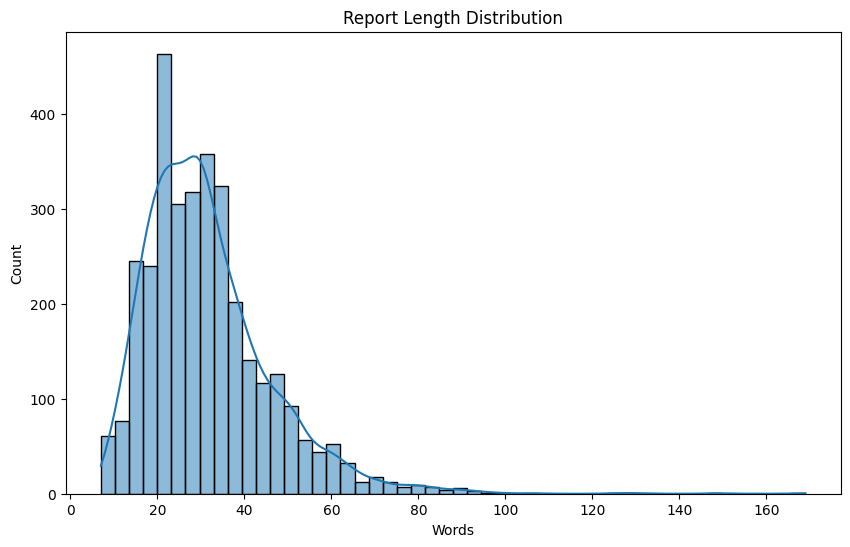

In [ ]:
# Vẽ histogram phân bố độ dài
plt.figure(figsize=(10, 6))
sns.histplot(df["report_length"], bins=50, kde=True)
plt.title("Report Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()


In [ ]:
# Xem percentile để đặt MAX_LEN cho hợp lý
print("90% report có độ dài <=", np.percentile(df["report_length"], 90), "từ")
print("95% report có độ dài <=", np.percentile(df["report_length"], 95), "từ")
print("99% report có độ dài <=", np.percentile(df["report_length"], 99), "từ")


90% report có độ dài <= 50.0 từ
95% report có độ dài <= 59.0 từ
99% report có độ dài <= 79.0 từ


## 8. Quét toàn bộ file ảnh trong thư mục

Lấy danh sách tất cả file `.png` để map với `uid`.


In [ ]:
all_images = []

for root, dirs, files in os.walk(IMG_DIR):
    for file in files:
        if file.endswith(".png"):
            all_images.append(os.path.join(root, file))

print("Tổng số ảnh:", len(all_images))
print("Ví dụ 5 đường dẫn đầu:")
for p in all_images[:5]:
    print(" ", p)


Tổng số ảnh: 7470
Ví dụ 5 đường dẫn đầu:
  /kaggle/input/chest-xrays-indiana-university/images/images_normalized/349_IM-1697-2001.dcm.png
  /kaggle/input/chest-xrays-indiana-university/images/images_normalized/607_IM-2196-1001.dcm.png
  /kaggle/input/chest-xrays-indiana-university/images/images_normalized/2832_IM-1249-2001.dcm.png
  /kaggle/input/chest-xrays-indiana-university/images/images_normalized/699_IM-2263-2001.dcm.png
  /kaggle/input/chest-xrays-indiana-university/images/images_normalized/1931_IM-0602-2001.dcm.png


## 9. Map `uid` → đường dẫn ảnh


In [ ]:
# Tạo dict {uid: list of image paths} để tra cứu nhanh
from collections import defaultdict

uid_to_paths = defaultdict(list)
for path in all_images:
    filename = os.path.basename(path)
    # Filename dạng: "1_IM-0001-3001.dcm.png" → uid = "1"
    if "_" in filename:
        uid_part = filename.split("_")[0]
        uid_to_paths[uid_part].append(path)

def get_image_path(uid):
    """Lấy đường dẫn ảnh đầu tiên ứng với uid (match chính xác)."""
    paths = uid_to_paths.get(str(uid), [])
    return paths[0] if paths else None

# Test thử
print("Ví dụ: uid=1 →", get_image_path(1))


Ví dụ: uid=1 → /kaggle/input/chest-xrays-indiana-university/images/images_normalized/1_IM-0001-3001.dcm.png


In [ ]:
# Áp dụng cho toàn bộ DataFrame
df["image_path"] = df["uid"].apply(get_image_path)

# Bỏ những row không tìm thấy ảnh
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Số sample sau khi map ảnh:", len(df))
df.head()


Số sample sau khi map ảnh: 3337


,uid,findings,report_length,image_path
0,1,The cardiac silhouette and mediastinum size ar...,34,/kaggle/input/chest-xrays-indiana-university/i...
1,2,Borderline cardiomegaly. Midline sternotomy XX...,14,/kaggle/input/chest-xrays-indiana-university/i...
2,4,There are diffuse bilateral interstitial and a...,64,/kaggle/input/chest-xrays-indiana-university/i...
3,5,The cardiomediastinal silhouette and pulmonary...,42,/kaggle/input/chest-xrays-indiana-university/i...
4,6,Heart size and mediastinal contour are within ...,32,/kaggle/input/chest-xrays-indiana-university/i...


## 10. Hiển thị một ảnh mẫu để kiểm tra

Kích thước ảnh: (2048, 2496)
Report: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pne ...


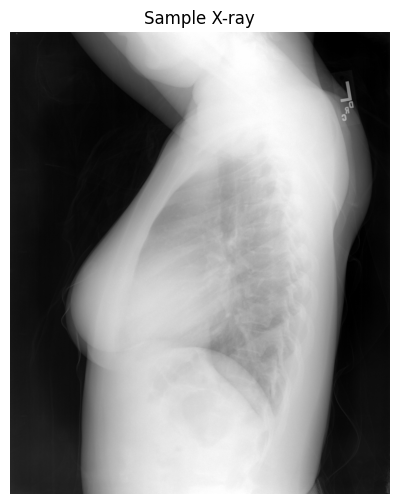

In [ ]:
sample_img = Image.open(df.iloc[0]["image_path"])
print("Kích thước ảnh:", sample_img.size)
print("Report:", df.iloc[0]["findings"][:200], "...")

plt.figure(figsize=(6, 6))
plt.imshow(sample_img, cmap="gray")
plt.axis("off")
plt.title("Sample X-ray")
plt.show()


## 11. Chia tập Train / Val / Test

- Train: 80%, Val: 10%, Test: 10%.
- `random_state=42` để kết quả reproducible.


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))


Train: 2669 | Val: 334 | Test: 334


## 12. Hàm tokenize bằng spaCy

Lowercase + tách từ, bỏ khoảng trắng.


In [ ]:
nlp = spacy.load("en_core_web_sm")

def tokenize(text):
    doc = nlp(text.lower())
    return [token.text for token in doc if not token.is_space]

# Test
print(tokenize("The lungs are clear. No pleural effusion."))


['the', 'lungs', 'are', 'clear', '.', 'no', 'pleural', 'effusion', '.']


## 13. Xây dựng vocabulary

- Token đặc biệt: `<pad>`, `<sos>`, `<eos>`, `<unk>`.
- Chỉ giữ từ xuất hiện ≥ `VOCAB_MIN_FREQ` lần.


In [ ]:
counter = Counter()

# Đếm từ trên TRAIN ONLY (tránh leak từ val/test)
for text in tqdm(train_df["findings"], desc="Tokenizing"):
    counter.update(tokenize(text))

special_tokens = ["<pad>", "<sos>", "<eos>", "<unk>"]

vocab = {}
idx2word = {}

# Thêm special tokens trước (idx 0-3)
for token in special_tokens:
    idx = len(vocab)
    vocab[token] = idx
    idx2word[idx] = token

# Thêm các từ thường (theo tần suất giảm dần để dễ debug)
for word, freq in counter.most_common():
    if freq >= VOCAB_MIN_FREQ:
        idx = len(vocab)
        vocab[word] = idx
        idx2word[idx] = word

print("VOCAB SIZE:", len(vocab))


Tokenizing: 100%|██████████| 2669/2669 [00:32<00:00, 82.51it/s] 

VOCAB SIZE: 839


## 14. Hàm chuyển text → list of token IDs

Format: `<sos> token1 token2 ... <eos>`


In [ ]:
PAD_IDX = vocab["<pad>"]
SOS_IDX = vocab["<sos>"]
EOS_IDX = vocab["<eos>"]
UNK_IDX = vocab["<unk>"]

def numericalize(text):
    ids = [SOS_IDX]
    for token in tokenize(text):
        ids.append(vocab.get(token, UNK_IDX))
    ids.append(EOS_IDX)

    # Cắt nếu quá dài (giữ EOS ở cuối)
    if len(ids) > MAX_LEN:
        ids = ids[:MAX_LEN - 1] + [EOS_IDX]

    return ids

# Test
print(numericalize("The lungs are clear.")[:20])


[1, 5, 20, 8, 24, 4, 2]


## 15. Transform ảnh

- Resize 224×224 (chuẩn của DenseNet/ImageNet).
- Normalize bằng mean/std của ImageNet.


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # → tensor [0, 1], shape [C, H, W]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet stats
        std=[0.229, 0.224, 0.225]
    )
])


## 16. PyTorch Dataset class

Đọc ảnh + caption, return tensor.


In [ ]:
class XrayDataset(Dataset):
    def __init__(self, dataframe):
        # Reset index để iloc luôn đúng
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Convert sang RGB (ảnh X-ray gốc là grayscale, nhưng DenseNet cần 3 kênh)
        image = Image.open(row["image_path"]).convert("RGB")
        image = transform(image)

        caption = torch.tensor(numericalize(row["findings"]), dtype=torch.long)

        return image, caption


## 17. Collate function — pad caption trong cùng batch

Trong cùng 1 batch, các caption có độ dài khác nhau → cần pad bằng `<pad>`.


In [ ]:
def collate_fn(batch):
    images = []
    captions = []

    for img, cap in batch:
        images.append(img)
        captions.append(cap)

    images = torch.stack(images)  # [B, 3, 224, 224]

    # pad_sequence: pad bên phải, batch_first=True → shape [B, max_len_in_batch]
    captions = pad_sequence(
        captions,
        batch_first=True,
        padding_value=PAD_IDX
    )

    return images, captions


## 18. Tạo DataLoader


In [ ]:
train_loader = DataLoader(
    XrayDataset(train_df),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    XrayDataset(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    XrayDataset(test_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

print(" DataLoader Ready")


 DataLoader Ready


In [ ]:
# Sanity check: lấy 1 batch xem shape
images, captions = next(iter(train_loader))
print("Images shape:", images.shape)      # [B, 3, 224, 224]
print("Captions shape:", captions.shape)  # [B, max_len_in_batch]


Images shape: torch.Size([16, 3, 224, 224])
Captions shape: torch.Size([16, 99])


## 19. Encoder CNN — DenseNet121

 **Đã sửa**: Dùng `weights=DenseNet121_Weights.DEFAULT` (API mới của torchvision) thay cho `pretrained=True` (deprecated).

- DenseNet121 trả về feature map shape `[B, 1024, 7, 7]` cho input 224×224.
- Reshape thành `[B, 49, 1024]` để Attention module xử lý 49 vùng ảnh.
- Freeze toàn bộ encoder để chỉ train decoder (tiết kiệm memory + tránh overfit).


In [ ]:
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Dùng API mới (torchvision >= 0.13)
        densenet = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
        self.features = densenet.features

        # Freeze toàn bộ encoder
        for param in self.features.parameters():
            param.requires_grad = False

        # Pool về 7×7 cho chắc chắn (DenseNet121 đã ra 7×7 với input 224, nhưng để safe)
        self.pool = nn.AdaptiveAvgPool2d((7, 7))

    def forward(self, images):
        features = self.features(images)        # [B, 1024, 7, 7]
        features = self.pool(features)          # [B, 1024, 7, 7]

        batch_size = features.size(0)
        features = features.view(batch_size, 1024, -1)   # [B, 1024, 49]
        features = features.permute(0, 2, 1)             # [B, 49, 1024]

        return features


## 20. Attention module (Bahdanau-style / Soft Attention)

Tại mỗi step decode, attention tính trọng số cho 49 vùng ảnh dựa trên hidden state hiện tại của LSTM.

**Công thức:**
```
e_i = v^T · tanh(W_a · encoder_out_i + W_h · hidden)
α   = softmax(e)
context = Σ α_i · encoder_out_i
```


In [ ]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, hidden_dim, attention_dim):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(hidden_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, hidden):
        # encoder_out: [B, 49, encoder_dim=1024]
        # hidden:      [B, hidden_dim=512]

        att1 = self.encoder_att(encoder_out)            # [B, 49, attention_dim]
        att2 = self.decoder_att(hidden).unsqueeze(1)    # [B, 1, attention_dim]

        # Cộng broadcast → [B, 49, attention_dim] → [B, 49]
        att = self.full_att(self.relu(att1 + att2)).squeeze(2)

        alpha = self.softmax(att)                       # [B, 49] — trọng số attention

        # context = weighted sum of encoder_out
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # [B, encoder_dim]

        return context, alpha


## 21. Decoder LSTM với Attention

Tại mỗi step `t`:
1. Tính context vector từ attention.
2. Concat context với embedding của từ trước → input cho LSTMCell.
3. Update `(h, c)`.
4. Linear → vocab → predicted word.


In [ ]:
class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, encoder_dim=1024):
        super().__init__()

        self.attention = Attention(encoder_dim, hidden_size, ATTENTION_DIM)

        # padding_idx → embedding của <pad> luôn là 0, không update
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)

        # LSTMCell vì ta loop từng step (cần attention tại mỗi step)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)

        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, encoder_out, captions):
        """
        encoder_out: [B, 49, 1024]
        captions:    [B, T]   (đã shift, không gồm token cuối)
        Return:      [B, T, vocab_size]
        """
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)
        vocab_size = self.fc.out_features  # ← lấy từ layer thay vì biến global cho an toàn

        embeddings = self.embedding(captions)  # [B, T, embed_size]

        # Khởi tạo hidden state = 0 (có thể init từ encoder mean cho tốt hơn)
        h = torch.zeros(batch_size, HIDDEN_SIZE, device=encoder_out.device)
        c = torch.zeros(batch_size, HIDDEN_SIZE, device=encoder_out.device)

        outputs = torch.zeros(batch_size, seq_len, vocab_size, device=encoder_out.device)

        # Teacher forcing: dùng ground truth làm input cho mỗi step
        for t in range(seq_len):
            context, alpha = self.attention(encoder_out, h)  # [B, 1024]

            lstm_input = torch.cat([embeddings[:, t], context], dim=1)  # [B, embed+1024]

            h, c = self.lstm(lstm_input, (h, c))

            preds = self.fc(self.dropout(h))   # [B, vocab_size]
            outputs[:, t] = preds

        return outputs


## 22. Khởi tạo model, loss, optimizer

- `CrossEntropyLoss` với `ignore_index=PAD_IDX`: không tính loss trên token padding.
- Optimizer chỉ update **decoder** (encoder đã freeze).


In [ ]:
encoder = EncoderCNN().to(DEVICE)
decoder = DecoderLSTM(
    vocab_size=len(vocab),
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Chỉ update decoder (encoder đã freeze)
optimizer = optim.Adam(decoder.parameters(), lr=LR)

print(" Model initialized")
print(f"Decoder trainable params: {sum(p.numel() for p in decoder.parameters() if p.requires_grad):,}")


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 135MB/s]


 Model initialized
Decoder trainable params: 5,107,272


## 23. Hàm validate

Tính loss trên tập validation. Dùng để chọn best model.


In [ ]:
def validate():
    encoder.eval()
    decoder.eval()

    total_loss = 0
    n_batches = 0

    with torch.no_grad():
        for images, captions in tqdm(val_loader, desc="Validating", leave=False):
            images = images.to(DEVICE)
            captions = captions.to(DEVICE)

            encoder_out = encoder(images)

            # Input:  <sos> w1 w2 ... wn-1
            # Target: w1 w2 ... wn-1 <eos>
            outputs = decoder(encoder_out, captions[:, :-1])

            loss = criterion(
                outputs.reshape(-1, len(vocab)),
                captions[:, 1:].reshape(-1)
            )

            total_loss += loss.item()
            n_batches += 1

    return total_loss / max(n_batches, 1)


## 24. Training loop




In [ ]:
import os

best_val_loss = float("inf")
train_losses = []
val_losses = []

CHECKPOINT_PATH = os.path.join(SAVE_DIR, "best_model_lstm.pth")

for epoch in range(EPOCHS):
    # Encoder luôn ở eval mode (đã freeze)
    encoder.eval()
    decoder.train()

    total_loss = 0
    n_batches = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for images, captions in loop:
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)

        # Forward
        encoder_out = encoder(images)
        outputs = decoder(encoder_out, captions[:, :-1])

        # Tính loss (bỏ token đầu <sos>, target shift sang phải)
        loss = criterion(
            outputs.reshape(-1, len(vocab)),
            captions[:, 1:].reshape(-1)
        )

        # Backward
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping để tránh exploding gradient
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()
        n_batches += 1
        loop.set_postfix(loss=loss.item())

    train_loss = total_loss / max(n_batches, 1)
    val_loss = validate()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Lưu best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "encoder": encoder.state_dict(),
            "decoder": decoder.state_dict(),
            "vocab": vocab,
            "idx2word": idx2word,
            "epoch": epoch + 1,
            "val_loss": val_loss,
        }, CHECKPOINT_PATH)
        print(f"   BEST MODEL SAVED → {CHECKPOINT_PATH}")


Epoch [1/30]: 100%|██████████| 167/167 [03:35<00:00,  1.29s/it, loss=3.64]


Epoch 1 | Train Loss: 4.7779 | Val Loss: 3.8484
   BEST MODEL SAVED → /content/drive/MyDrive/xray_captioning/best_model_lstm.pth


Epoch [2/30]: 100%|██████████| 167/167 [03:24<00:00,  1.23s/it, loss=3.04]


Epoch 2 | Train Loss: 3.4877 | Val Loss: 3.1430
   BEST MODEL SAVED → /content/drive/MyDrive/xray_captioning/best_model_lstm.pth


Epoch [3/30]: 100%|██████████| 167/167 [03:21<00:00,  1.21s/it, loss=2.73]


...

Epoch 28 | Train Loss: 1.3213 | Val Loss: 1.7170


Epoch [29/30]: 100%|██████████| 167/167 [03:16<00:00,  1.17s/it, loss=1.13]


Epoch 29 | Train Loss: 1.2961 | Val Loss: 1.7272


Epoch [30/30]: 100%|██████████| 167/167 [03:13<00:00,  1.16s/it, loss=1.05]
                                                           

Epoch 30 | Train Loss: 1.2650 | Val Loss: 1.7258


In [ ]:
print(" Training Finished")
print("Best val loss:", best_val_loss)


 Training Finished
Best val loss: 1.716648987361363


## 25. Vẽ đường loss train vs val

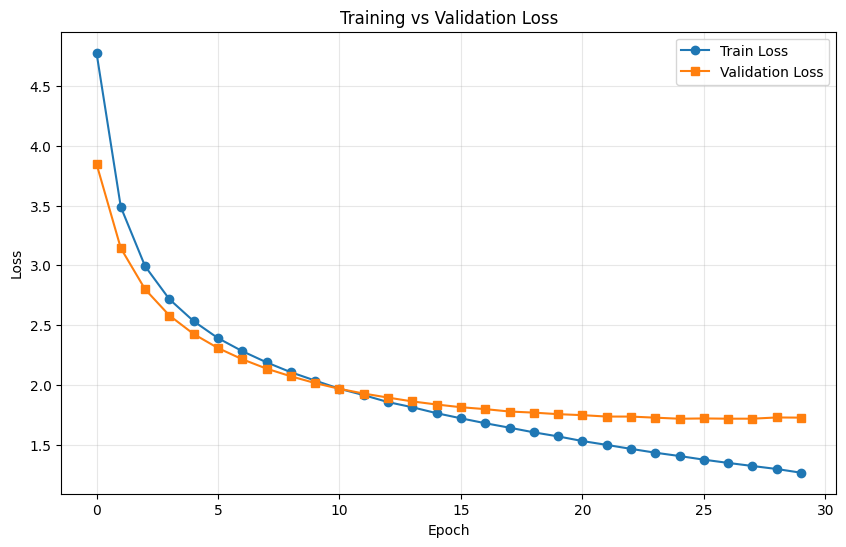

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='s')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 26. Hàm sinh caption — Greedy decoding

Tại mỗi step, chọn từ có xác suất cao nhất (`argmax`). Dừng khi gặp `<eos>` hoặc đạt `max_len`.



In [ ]:
def generate_caption(image_path, max_len=80):
    encoder.eval()
    decoder.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(DEVICE)  # [1, 3, 224, 224]

    result = []

    with torch.no_grad():
        encoder_out = encoder(image)  # [1, 49, 1024]

        h = torch.zeros(1, HIDDEN_SIZE, device=DEVICE)
        c = torch.zeros(1, HIDDEN_SIZE, device=DEVICE)

        word = torch.tensor([SOS_IDX], device=DEVICE)

        for _ in range(max_len):
            embedding = decoder.embedding(word)  # [1, embed_size]

            context, alpha = decoder.attention(encoder_out, h)

            lstm_input = torch.cat([embedding, context], dim=1)
            h, c = decoder.lstm(lstm_input, (h, c))

            preds = decoder.fc(h)
            predicted = preds.argmax(1)
            word_idx = predicted.item()

            # Dừng khi gặp EOS
            if word_idx == EOS_IDX:
                break

            result.append(idx2word.get(word_idx, "<unk>"))
            word = predicted

    return " ".join(result)


## 27. Test sinh caption trên 1 ảnh test

 Ground Truth:
Stable enlargement of the cardiac silhouette, lateral view interlobar fissural thickening. Interstitial opacities greatest in the central lungs and bases.

 Generated Report:
the heart is normal in size . the mediastinum is unremarkable . the lungs are clear .


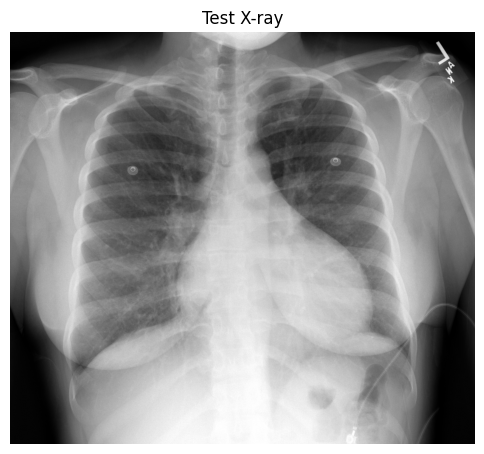

In [ ]:
sample_path = test_df.iloc[0]["image_path"]

print(" Ground Truth:")
print(test_df.iloc[0]["findings"])

print("\n Generated Report:")
print(generate_caption(sample_path))

# Hiển thị ảnh
plt.figure(figsize=(6, 6))
plt.imshow(Image.open(sample_path), cmap="gray")
plt.axis("off")
plt.title("Test X-ray")
plt.show()


## 28. Lưu model cuối cùng (final, không phải best)

In [ ]:
FINAL_PATH = os.path.join(SAVE_DIR, "final_model_lstm.pth")
torch.save({
    "encoder": encoder.state_dict(),
    "decoder": decoder.state_dict(),
    "vocab": vocab,
    "idx2word": idx2word,
}, FINAL_PATH)
print(f" Model saved successfully → {FINAL_PATH}")


 Model saved successfully → /content/drive/MyDrive/xray_captioning/final_model_lstm.pth


## 29. Đánh giá model — Import thư viện metrics

- **BLEU**: đo n-gram overlap (1-gram đến 4-gram).
- **ROUGE-L**: longest common subsequence.
- **METEOR**: dùng synonym matching.
- **BERTScore**: dùng BERT embedding (phù hợp cho text y khoa).


In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bertscore

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

print(" Đã tải xong NLTK data")


 Đã tải xong NLTK data


## 30. Sinh prediction cho toàn bộ test set

 Cell này có thể chạy lâu (vài phút đến vài chục phút tùy size của test set).


In [ ]:
references = []      # cho BLEU: list of [list of tokens]
predictions = []     # cho BLEU: list of tokens

for i in tqdm(range(len(test_df)), desc="Generating predictions"):
    image_path = test_df.iloc[i]["image_path"]
    gt_report = test_df.iloc[i]["findings"]

    pred_report = generate_caption(image_path)

    # Format cho corpus_bleu: references[i] là LIST các reference (vì có thể có nhiều)
    references.append([gt_report.lower().split()])
    predictions.append(pred_report.lower().split())

print(" Đã sinh xong", len(predictions), "predictions")


Generating predictions: 100%|██████████| 334/334 [00:38<00:00,  8.69it/s]

 Đã sinh xong 334 predictions


## 31. Tính BLEU-1 và BLEU-4

`SmoothingFunction.method1` để tránh score = 0 khi không có 4-gram match.


In [ ]:
smooth = SmoothingFunction().method1

bleu1 = corpus_bleu(
    references, predictions,
    weights=(1, 0, 0, 0),
    smoothing_function=smooth
)

bleu4 = corpus_bleu(
    references, predictions,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smooth
)

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-4: {bleu4:.4f}")


BLEU-1: 0.2426
BLEU-4: 0.0552


## 32. Tính ROUGE-L

`use_stemmer=True` để match tốt hơn (e.g. "lung" ↔ "lungs").


In [ ]:
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

rouge_scores = []
for i in tqdm(range(len(test_df)), desc="Computing ROUGE-L"):
    gt = test_df.iloc[i]["findings"]
    pred = " ".join(predictions[i])

    score = scorer.score(gt, pred)
    rouge_scores.append(score["rougeL"].fmeasure)

rouge_l = float(np.mean(rouge_scores))
print(f"ROUGE-L: {rouge_l:.4f}")


Computing ROUGE-L: 100%|██████████| 334/334 [00:00<00:00, 1128.04it/s]

ROUGE-L: 0.2782


## 33. Tính METEOR



In [ ]:
meteor_scores = []

for i in tqdm(range(len(test_df)), desc="Computing METEOR"):
    gt_tokens = test_df.iloc[i]["findings"].lower().split()
    pred_tokens = predictions[i]  # đã là list of tokens

    # meteor_score nhận list of references, mỗi reference là list of tokens
    score = meteor_score([gt_tokens], pred_tokens)
    meteor_scores.append(score)

meteor_avg = float(np.mean(meteor_scores))
print(f"METEOR: {meteor_avg:.4f}")


Computing METEOR: 100%|██████████| 334/334 [00:04<00:00, 78.16it/s] 

METEOR: 0.2000


## 34. Tính BERTScore

BERTScore sẽ tải model BERT (~440MB) lần đầu. Dùng GPU sẽ nhanh hơn.


In [ ]:
refs_text = [test_df.iloc[i]["findings"] for i in range(len(test_df))]
preds_text = [" ".join(predictions[i]) for i in range(len(test_df))]

P, R, F1 = bertscore(
    preds_text, refs_text,
    lang="en",
    verbose=True
)

bert_f1 = F1.mean().item()
print(f"BERTScore F1: {bert_f1:.4f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/7 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/6 [00:00<?, ?it/s]

done in 6.10 seconds, 54.72 sentences/sec
BERTScore F1: 0.8689


## 35. Tổng hợp & Visualize tất cả metrics

Metric               Score
BLEU-1              0.2426
BLEU-4              0.0552
ROUGE-L             0.2782
METEOR              0.2000
BERTScore           0.8689


/tmp/ipykernel_9250/1086779815.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="viridis")


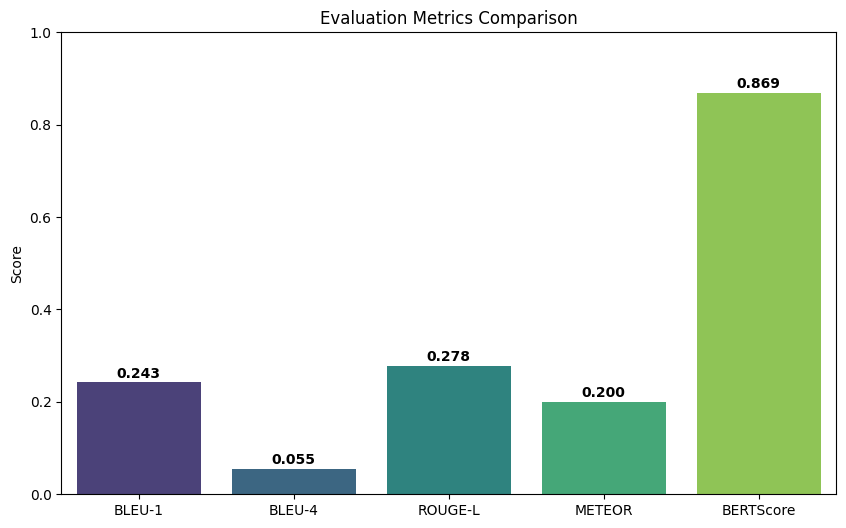

In [ ]:
metrics = ["BLEU-1", "BLEU-4", "ROUGE-L", "METEOR", "BERTScore"]
values = [bleu1, bleu4, rouge_l, meteor_avg, bert_f1]

# In bảng
print("=" * 40)
print(f"{'Metric':<15} {'Score':>10}")
print("=" * 40)
for m, v in zip(metrics, values):
    print(f"{m:<15} {v:>10.4f}")
print("=" * 40)

# Vẽ bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=metrics, y=values, palette="viridis")
plt.title("Evaluation Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")

plt.show()


## 36. (Bonus) Hiển thị vài ví dụ Ground Truth vs Prediction

In [ ]:
N_SHOW = 5

for i in range(N_SHOW):
    print(f"\n{'='*60}")
    print(f"Sample {i+1}")
    print('='*60)
    print(f" GT:   {test_df.iloc[i]['findings']}")
    print(f" PRED: {' '.join(predictions[i])}")



Sample 1
 GT:   Stable enlargement of the cardiac silhouette, lateral view interlobar fissural thickening. Interstitial opacities greatest in the central lungs and bases.
 PRED: the heart is normal in size . the mediastinum is unremarkable . the lungs are clear .

Sample 2
 GT:   The lungs are clear bilaterally. Specifically, no evidence of focal consolidation, pneumothorax, or pleural effusion.. Cardio mediastinal silhouette is unremarkable. Visualized osseous structures of the thorax are without acute abnormality.
 PRED: the heart size is normal . the lungs are clear . no pneumothorax or pleural effusion .

Sample 3
 GT:   The heart and lungs have XXXX XXXX in the interval. Both lungs are clear and expanded. Heart and mediastinum normal.
 PRED: the lungs are clear . there is no pleural effusion or pneumothorax . the heart and mediastinum are normal . the skeletal structures are normal .

Sample 4
 GT:   Technically limited study secondary to patient XXXX. Decreased lung volumes with